In [13]:
# Cell 1: imports and global settings
import os
import io
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

import torch
from transformers import CLIPProcessor, CLIPModel

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

#paths and column names
CSV_PATH      = "meta.csv"
URL_COL       = "url"
YEAR_COL      = "GT"

#sampling / model settings
SAMPLE_PER_YEAR = 250
IMAGE_FOLDER    = "downloaded_images"
BATCH_SIZE      = 32
NUM_THREADS     = 16
PCA_COMPONENTS  = 256
START_YEAR      = 1930

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(IMAGE_FOLDER, exist_ok=True)
print("Using device:", DEVICE)


Using device: cpu


In [ ]:
# Cell 2: loading the metadata csv and creating a stratified random sample

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=[URL_COL, YEAR_COL])
df[YEAR_COL] = df[YEAR_COL].astype(int)

df = (
    df.groupby(YEAR_COL, group_keys=False)
      .apply(lambda g: g.sample(n=min(SAMPLE_PER_YEAR, len(g)), random_state=42))
      .reset_index(drop=True)
)

print("Rows selected:", len(df))
df.head()


In [ ]:
# Cell 3: parallel image downloading

def download_one(row):
    idx      = row.name
    url      = row[URL_COL]
    save_path = os.path.join(IMAGE_FOLDER, f"{idx}.jpg")

    if os.path.exists(save_path):
        return save_path

    try:
        r   = requests.get(url, timeout=10)
        img = Image.open(io.BytesIO(r.content)).convert("RGB")
        img.save(save_path, quality=90)
        return save_path
    except Exception as e:
        print(f"Failed on {save_path}: {e}")
        return None

rows = [row for _, row in df.iterrows()]

saved_paths = []
with ThreadPoolExecutor(max_workers=NUM_THREADS) as ex:
    for result in tqdm(ex.map(download_one, rows), total=len(rows)):
        saved_paths.append(result)

df["local_path"] = saved_paths
df = df.dropna(subset=["local_path"]).reset_index(drop=True)  # to drop any failed downloads

print("Images ready:", len(df))
df.to_csv("sample_ready.csv", index=False)


In [ ]:
# Cell 4: loading the CLIP model and processor
model_name = "openai/clip-vit-base-patch32"

clip_model     = CLIPModel.from_pretrained(model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(model_name)
clip_model.eval()

print("CLIP loaded on", DEVICE)


In [ ]:
# Cell 5: extracting CLIP image embeddings in batches

df    = pd.read_csv("sample_ready.csv")
paths = df["local_path"].tolist()
years = df[YEAR_COL].tolist()

embeddings = []
targets    = []

for i in tqdm(range(0, len(paths), BATCH_SIZE)):
    batch_paths = paths[i : i + BATCH_SIZE]
    batch_years = years[i : i + BATCH_SIZE]

    imgs = []
    yrs  = []

    for p, y in zip(batch_paths, batch_years):
        try:
            img = Image.open(p).convert("RGB")
            imgs.append(img)
            yrs.append(y)
        except Exception as e:
            print(f"Failed on {p}: {e}")   #noting the failure, then skipping it

    if not imgs:
        continue

    inputs = clip_processor(images=imgs, return_tensors="pt", padding=True).to(DEVICE)

    with torch.no_grad():
        feats = clip_model.get_image_features(**inputs)

    if not isinstance(feats, torch.Tensor):
        feats = feats.pooler_output

    feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
    feats = feats.cpu().numpy()

    embeddings.extend(feats)
    targets.extend(yrs)

X_clip = np.array(embeddings)
y      = np.array(targets)

print("CLIP embeddings shape:", X_clip.shape)

np.save("X_clip.npy", X_clip)
np.save("y_years.npy", y)


In [14]:
# Cell 6: extracting handcrafted image features and building the combined feature matrix

df = pd.read_csv("sample_ready.csv")

def extract_numeric_features(path):
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        h, w, _ = arr.shape

        # basic global statistics
        mean  = arr.mean()
        std   = arr.std()
        minv  = arr.min()
        maxv  = arr.max()

        # per-channel means and standard deviations
        r_mean, g_mean, b_mean = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
        r_std,  g_std,  b_std  = arr[:,:,0].std(),  arr[:,:,1].std(),  arr[:,:,2].std()

        # perceptual brightness and contrast
        brightness = 0.299*r_mean + 0.587*g_mean + 0.114*b_mean
        contrast   = std

        # shape
        aspect = w / h
        area   = h * w

        # edge strength via finite differences
        gx = np.abs(np.diff(arr, axis=1)).mean()
        gy = np.abs(np.diff(arr, axis=0)).mean()
        edge_strength = gx + gy

        # colour-channel spread
        rg_diff = abs(r_mean - g_mean)
        rb_diff = abs(r_mean - b_mean)
        gb_diff = abs(g_mean - b_mean)

        # 8-bin normalised histograms per channel (which means 24 values total)
        hist_r = np.histogram(arr[:,:,0], bins=8, range=(0,255))[0]
        hist_g = np.histogram(arr[:,:,1], bins=8, range=(0,255))[0]
        hist_b = np.histogram(arr[:,:,2], bins=8, range=(0,255))[0]
        hist_features = np.concatenate([hist_r, hist_g, hist_b]) / (h * w)

        # texture -  variance of first-order gradients
        texture = (np.var(np.diff(arr.astype(float), axis=0))
                 + np.var(np.diff(arr.astype(float), axis=1)))

        return np.concatenate([
            [mean, std, minv, maxv,
             r_mean, g_mean, b_mean,
             r_std,  g_std,  b_std,
             brightness, contrast,
             aspect, area,
             gx, gy, edge_strength,
             rg_diff, rb_diff, gb_diff,
             texture],
            hist_features   # 24 histogram bins
            #we have a total 
        ])

    except Exception as e:
        print(f"Failed on {path}: {e}")
        return None   # dropping this sample

num_feats_raw = []
valid_paths   = []

for p in tqdm(df["local_path"]):
    f = extract_numeric_features(p)
    if f is not None:   
        num_feats_raw.append(f)
        valid_paths.append(p)

num_feats_raw = np.array(num_feats_raw)
print("Handcrafted feature matrix shape:", num_feats_raw.shape)

# reloading CLIP embeddings
X_clip_full = np.load("X_clip.npy")
y_full      = np.load("y_years.npy")

# build index mask so CLIP rows match the rows we kept above
df["feat_ok"] = [p in valid_paths for p in df["local_path"]]
mask = df["feat_ok"].values

X_clip = X_clip_full[mask]
y      = y_full[mask]

print("Aligned CLIP shape:", X_clip.shape)
print("Aligned target shape:", y.shape)


100%|██████████| 14611/14611 [02:06<00:00, 115.63it/s]


Handcrafted feature matrix shape: (14611, 45)
Aligned CLIP shape: (14611, 512)
Aligned target shape: (14611,)


In [15]:
# Cell 7: train and test split, and then scaler + PCA

#converting years to 5-year bins
y_bins = ((y - START_YEAR) // 5).astype(int)

# holding out 20 percent for final evaluation
X_train_raw, X_test_raw, y_train, y_test, year_train, year_test = train_test_split(
    np.hstack([X_clip, num_feats_raw]),
    y_bins,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

#split CLIP and handcrafted columns
n_clip = X_clip.shape[1]

X_train_clip = X_train_raw[:, :n_clip]
X_train_hand = X_train_raw[:, n_clip:]
X_test_clip  = X_test_raw[:,  :n_clip]
X_test_hand  = X_test_raw[:,  n_clip:]

# scaler
scaler = StandardScaler()
X_train_hand = scaler.fit_transform(X_train_hand)
X_test_hand  = scaler.transform(X_test_hand)

X_train_combined = np.hstack([X_train_clip, X_train_hand])
X_test_combined  = np.hstack([X_test_clip,  X_test_hand])

# PCA on training data
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_train = pca.fit_transform(X_train_combined)
X_test  = pca.transform(X_test_combined)

scaler_hand = StandardScaler().fit(X_train_raw[:, n_clip:])
X_train_hand_scaled = scaler_hand.transform(X_train_raw[:, n_clip:])
X_test_hand_scaled  = scaler_hand.transform(X_test_raw[:,  n_clip:])

pca_hand = PCA(n_components=min(PCA_COMPONENTS, X_train_hand_scaled.shape[1]), random_state=42)
X_train_hand_pca = pca_hand.fit_transform(X_train_hand_scaled)
X_test_hand_pca  = pca_hand.transform(X_test_hand_scaled)

pca_clip = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_train_clip_pca = pca_clip.fit_transform(X_train_clip)
X_test_clip_pca  = pca_clip.transform(X_test_clip)

print("Training set shape:", X_train.shape)
print("Test set shape:    ", X_test.shape)
print(f"Class bins: {np.unique(y_train)}")


Training set shape: (11688, 256)
Test set shape:     (2923, 256)
Class bins: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


In [16]:
# Cell 8: all the baselines , and the Logistic Regression classifier

from scipy.interpolate import make_interp_spline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(X, y_b):
    """Return (mean_acc, std_acc) across 5 stratified folds."""
    scores = []
    for tr_idx, val_idx in skf.split(X, y_b):
        clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
        clf.fit(X[tr_idx], y_b[tr_idx])
        scores.append(clf.score(X[val_idx], y_b[val_idx]))
    return np.mean(scores), np.std(scores)

#baselines
print("\nBASELINES\n")


# random guessing
rand_clf = DummyClassifier(strategy="uniform", random_state=42)
rand_clf.fit(X_train, y_train)
rand_acc = rand_clf.score(X_test, y_test) * 100
print(f"Random guess accuracy      : {rand_acc:.2f}%")

# majority class predictor
maj_clf = DummyClassifier(strategy="most_frequent")
maj_clf.fit(X_train, y_train)
maj_acc = maj_clf.score(X_test, y_test) * 100
print(f"Majority class accuracy    : {maj_acc:.2f}%")

# handcrafted features only (with a 5-fold CV)
hand_mean, hand_std = cv_score(
    np.vstack([X_train_hand_pca, X_test_hand_pca]),
    np.concatenate([y_train, y_test])
)
print(f"Handcrafted-only (5-fold)  : {hand_mean*100:.2f}% ± {hand_std*100:.2f}%")

# CLIP features only (5-fold CV)
clip_mean, clip_std = cv_score(
    np.vstack([X_train_clip_pca, X_test_clip_pca]),
    np.concatenate([y_train, y_test])
)
print(f"CLIP-only (5-fold)         : {clip_mean*100:.2f}% ± {clip_std*100:.2f}%")

# combined features (5-fold CV)
comb_mean, comb_std = cv_score(
    np.vstack([X_train, X_test]),
    np.concatenate([y_train, y_test])
)
print(f"Combined (5-fold)          : {comb_mean*100:.2f}% ± {comb_std*100:.2f}%")

# now the full model
print()
print("\nFULL MODEL SUITE (trained on 80% split)\n")

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, C=2.0),
}

results = {}

for name, model in models.items():

    print("\nTraining:", name)

    # CV
    cv_scores = []

    for tr_idx, val_idx in skf.split(X_train, y_train):

        model.fit(X_train[tr_idx], y_train[tr_idx])

        cv_scores.append(
            model.score(X_train[val_idx], y_train[val_idx])
        )

    # final fitting
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)

    bin_centers = START_YEAR + np.arange(probs.shape[1]) * 5 + 2

    pred_year = []

    for p in probs:
        x_smooth = np.linspace(
            bin_centers.min(),
            bin_centers.max(),
            1000
        )

        spline = make_interp_spline(
            bin_centers,
            p,
            k=3
        )

        y_smooth = spline(x_smooth)

        # predicted year equals the curve peak
        peak_year = x_smooth[np.argmax(y_smooth)]

        pred_year.append(peak_year)

    pred_year = np.array(pred_year)


    # metrics
    mae = np.mean(np.abs(pred_year - year_test))

    acc5 = np.mean(
        np.abs(pred_year - year_test) <= 5
    ) * 100


    results[name] = {
        "pred_year": pred_year,
        "true_year": year_test,
        "mae": mae,
        "acc5": acc5,
        "cv_mean": np.mean(cv_scores),
        "cv_std": np.std(cv_scores),
    }

    print(f"  MAE                 : {mae:.2f} yrs")
    print(f"  ±5-year accuracy    : {acc5:.2f}%")


BASELINES

Random guess accuracy      : 6.71%
Majority class accuracy    : 7.80%
Handcrafted-only (5-fold)  : 28.44% ± 0.54%
CLIP-only (5-fold)         : 41.04% ± 0.28%
Combined (5-fold)          : 40.87% ± 1.26%


FULL MODEL SUITE (trained on 80% split)


Training: Logistic Regression
  MAE                 : 7.31 yrs
  ±5-year accuracy    : 58.74%


In [17]:
# Cell 9: the models for the other classifiers

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=250, n_jobs=-1, random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=250, n_jobs=-1, random_state=42
    ),
}

for name, model in models.items():

    print("\nTraining:", name)

    # CV
    cv_scores = []

    for tr_idx, val_idx in skf.split(X_train, y_train):

        model.fit(X_train[tr_idx], y_train[tr_idx])

        cv_scores.append(
            model.score(X_train[val_idx], y_train[val_idx])
        )

    # final fit
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)

    bin_centers = START_YEAR + np.arange(probs.shape[1]) * 5 + 2

    pred_year = []

    for p in probs:

        # smooth temporal probability curve
        x_smooth = np.linspace(
            bin_centers.min(),
            bin_centers.max(),
            1000
        )

        spline = make_interp_spline(
            bin_centers,
            p,
            k=3
        )

        y_smooth = spline(x_smooth)

        # predicted year equals curve peak
        peak_year = x_smooth[np.argmax(y_smooth)]

        pred_year.append(peak_year)

    pred_year = np.array(pred_year)

    # metrics
    mae = np.mean(np.abs(pred_year - year_test))

    acc5 = np.mean(
        np.abs(pred_year - year_test) <= 5
    ) * 100


    results[name] = {
        "pred_year": pred_year,
        "true_year": year_test,
        "mae": mae,
        "acc5": acc5,
        "cv_mean": np.mean(cv_scores),
        "cv_std": np.std(cv_scores),
    }

    print(f"  MAE                 : {mae:.2f} yrs")
    print(f"  ±5-year accuracy    : {acc5:.2f}%")


Training: Random Forest
  MAE                 : 8.29 yrs
  ±5-year accuracy    : 57.92%

Training: Extra Trees
  MAE                 : 7.94 yrs
  ±5-year accuracy    : 57.37%


In [28]:
# Cell 10: small pytorch classifier, just to compare with the other methods

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Using device:", DEVICE)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

class Net(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 32),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)

n_classes = len(np.unique(y_train))
net = Net(X_train.shape[1], n_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01) 

EPOCHS = 50

for epoch in range(EPOCHS):
    net.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(net(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss = {total_loss:.4f}")

net.eval()
with torch.no_grad():
    logits    = net(X_test_t.to(DEVICE))
    pred_bins = torch.argmax(logits, dim=1).cpu().numpy()

pred_year = START_YEAR + pred_bins * 5 + 2

mae     = np.mean(np.abs(pred_year - year_test))
acc5    = np.mean(np.abs(pred_year - year_test) <= 5) * 100

results["Neural Network"] = {
    "pred_year" : pred_year,
    "pred_bins" : pred_bins,
    "true_year" : year_test,
    "mae"       : mae,
    "acc5"      : acc5,
}

print(f"MAE                 : {mae:.2f} yrs")
print(f"±5-year accuracy    : {acc5:.2f}%")


Using device: cpu
Epoch  10/50  loss = 1716.8072
Epoch  20/50  loss = 1508.0367
Epoch  30/50  loss = 1437.1933
Epoch  40/50  loss = 1393.4912
Epoch  50/50  loss = 1358.8281
MAE                 : 7.96 yrs
±5-year accuracy    : 52.75%


Best model: Logistic Regression
  MAE        : 7.31 yrs
  ±5-yr acc  : 58.74%


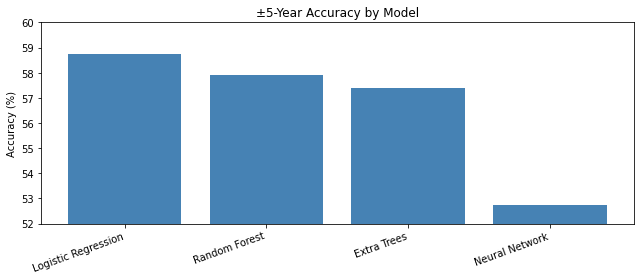

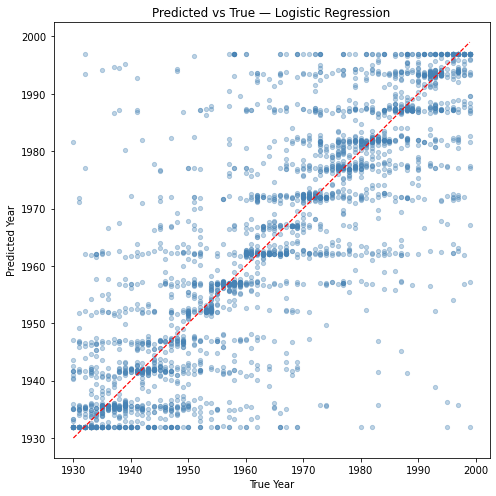

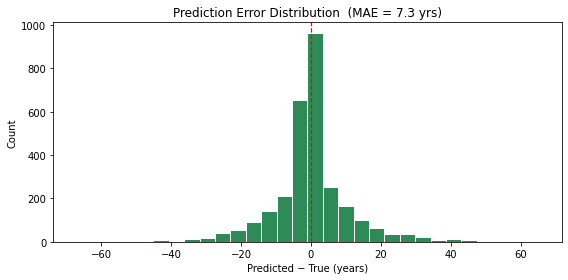


MAE summary across all models:
  Logistic Regression    MAE = 7.31 yrs   ±5yr = 58.7%
  Random Forest          MAE = 8.29 yrs   ±5yr = 57.9%
  Extra Trees            MAE = 7.94 yrs   ±5yr = 57.4%
  Neural Network         MAE = 7.96 yrs   ±5yr = 52.8%


In [31]:
# Cell 11: evaluation plots 

best = max(results, key=lambda x: results[x]["acc5"])

preds      = results[best]["pred_year"]
true_years = results[best]["true_year"]
errors     = preds - true_years

print(f"Best model: {best}")
print(f"  MAE        : {results[best]['mae']:.2f} yrs")
print(f"  ±5-yr acc  : {results[best]['acc5']:.2f}%")

# a bar chart: it shows a ±5-year accuracy across all models
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(results.keys(), [results[k]["acc5"] for k in results], color="steelblue")
ax.set_title("±5-Year Accuracy by Model")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(52, 60)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# a scatterplot: predicted vs true year for the best model
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(true_years, preds, alpha=0.35, s=18, color="steelblue")
mn = min(true_years.min(), preds.min())
mx = max(true_years.max(), preds.max())
ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.2)
ax.set_xlabel("True Year")
ax.set_ylabel("Predicted Year")
ax.set_title(f"Predicted vs True — {best}")
plt.tight_layout()
plt.show()


# a histogram of prediction errors
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(errors, bins=30, color="seagreen", edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_title("Prediction Error Distribution")
ax.set_xlabel("Predicted − True (years)")
ax.set_ylabel("Count")
mae_val = np.mean(np.abs(errors))
ax.set_title(f"Prediction Error Distribution  (MAE = {mae_val:.1f} yrs)")
plt.tight_layout()
plt.show()

print("\nMAE summary across all models:")
for name in results:
    print(f"  {name:<22} MAE = {results[name]['mae']:.2f} yrs   ±5yr = {results[name]['acc5']:.1f}%")


Using device: cpu
Epoch  10/50  loss = 1723.5557
Epoch  20/50  loss = 1524.9098
Epoch  30/50  loss = 1440.0167
Epoch  40/50  loss = 1401.7442
Epoch  50/50  loss = 1360.3031

5-year bin accuracy : 32.98%
MAE                 : 8.18 yrs
±5-year accuracy    : 50.63%
